# Cell type classification with MLPs.

## Setting up the notebook.

### Importing the libraries.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import torch

import sc_exp_design


### Constants.

In [ ]:
# working locally?
IS_RUN_LOCALLY = True

# paths
if IS_RUN_LOCALLY:
    H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"
else:
    H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# obs columns
SCATTER_COVARIATES = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']

# obsm columns
X_SCATTER_OBSM_KEY = "X_scatter"

# validation split
VALIDATION_SIZE = 3e-1
RANDOM_SEED = 42

# normalization
NORMALIZE_FEATURES = True

if IS_RUN_LOCALLY:
    DEVICE = "mps"
else:
    DEVICE = "cuda"


### Utility functions.

In [ ]:
def predict_with_mlp(mlp, X, le_cell_type):
    if not isinstance(X, torch.Tensor):
        X = torch.from_numpy(X).float().to(DEVICE)
    Y_logits =  mlp(X)["cell_type"]
    Y_pred_probs = torch.softmax(Y_logits, dim=1).detach().cpu().numpy()
    Y_pred_log_probs = torch.log_softmax(Y_logits, dim=1).detach().cpu().numpy()
    Y_pred_entropy = -np.sum(Y_pred_probs*Y_pred_log_probs, axis=-1)
    Y_pred_label = np.argmax(Y_pred_probs, axis=1)
    Y_pred = le_cell_type.inverse_transform(Y_pred_label)
    return Y_pred_probs, Y_pred_log_probs, Y_pred_entropy, Y_pred_label, Y_pred


def evaluate_classifier(
    lm, X, Y, Y_labels, le_cell_type
):
    
    Y_pred_probs, Y_pred_log_probs, Y_pred_entropy, Y_pred_label, Y_pred = predict_with_mlp(lm, X, le_cell_type)
    cm = confusion_matrix(
        Y,
        Y_pred,
        labels=le_cell_type.classes_,
    )
    accuracy = accuracy_score(Y, Y_pred)
    precision = precision_score(Y, Y_pred, average="weighted")
    recall = recall_score(Y, Y_pred, average="weighted")
    f1 = f1_score(Y, Y_pred, average="weighted")
    report = classification_report(Y, Y_pred, target_names=le_cell_type.classes_, output_dict=True)
    y_true_bin = label_binarize(
        [np.where(le_cell_type.classes_ == c)[0][0] for c in Y], classes=range(len(le_cell_type.classes_))
    )
    classes_roc_auc = {}
    classes_fpr = {}
    classes_tpr = {}
    for i, class_label in enumerate(le_cell_type.classes_):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], Y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        classes_roc_auc[class_label] = roc_auc
        classes_fpr[class_label] = fpr
        classes_tpr[class_label] = tpr
        # report[class_label]["tpr"] = tpr
        # report[class_label]["fpr"] = fpr
        report[class_label]["roc_auc"] = roc_auc
    macro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="macro")
    micro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="micro")
    return {
        "Y_pred_probs": Y_pred_probs,
        "Y_pred_log_probs": Y_pred_log_probs,
        "Y_pred_entropy": Y_pred_entropy,
        "Y_pred_label": Y_pred_label,
        "Y_pred": Y_pred,
        "cm": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "report": report,
        "classes_roc_auc": classes_roc_auc,
        "classes_tpr": classes_tpr,
        "classes_fpr": classes_fpr,
        "micro_roc_auc": micro_roc_auc,
        "macro_roc_auc": macro_roc_auc,
    }


def plot_class_misclassification_entropy(val_adata, eval_dict):
    y_true = val_adata.obs["cell_type"]

    for eval_type, metrics in eval_dict.items():
        print(f"Processing {eval_type}...")

        # Extract predictions and entropy
        y_pred = metrics["Y_pred"]
        entropy = metrics["Y_pred_entropy"]

        # Add to adata.obs
        val_adata.obs[f"{eval_type}_pred"] = y_pred
        val_adata.obs[f"{eval_type}_entropy"] = entropy

        for cell_type in y_true.cat.categories:
            # Masks
            class_mask = (y_true == cell_type)
            misclassified_mask = class_mask & (y_pred != y_true)

            if class_mask.sum() == 0:
                continue  # skip if no cells of this class

            # Left panel: highlight misclassified
            plot_col = []
            for i in range(len(val_adata)):
                if misclassified_mask[i]:
                    plot_col.append("misclassified")
                elif class_mask[i]:
                    plot_col.append("class")
                else:
                    plot_col.append("background")
            val_adata.obs[f"{eval_type}_{cell_type}_plot"] = plot_col

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            # Left: highlight misclassified cells
            sc.pl.embedding(
                val_adata,
                basis="umap",
                color=f"{eval_type}_{cell_type}_plot",
                size=30,
                alpha=0.8,
                ax=axes[0],
                show=False,
                palette={"background": "lightgray", "class": "lightblue", "misclassified": "orange"},
                legend_loc=None
            )
            axes[0].set_title(f"{eval_type}: {cell_type} (misclassified in orange)")

            # Right: all cells, entropy colored only for this class
            # Create a new column for plotting entropy: keep entropy for this class, else NaN
            entropy_plot = entropy.copy()
            entropy_plot[~class_mask] = float("nan")
            val_adata.obs[f"{eval_type}_{cell_type}_entropy_plot"] = entropy_plot

            sc.pl.embedding(
                val_adata,
                basis="umap",
                color=f"{eval_type}_{cell_type}_entropy_plot",
                size=30,
                alpha=0.8,
                ax=axes[1],
                show=False,
                cmap="viridis"
            )
            axes[1].set_title(f"{eval_type}: {cell_type} prediction entropy")

            plt.tight_layout()
            plt.show()

## Data.

### Reading data.

In [ ]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Storing scatter features in `obsm`.

In [ ]:
X_scatter = adata.obs[SCATTER_COVARIATES].values
adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter

### Label encoder for cell type.

In [ ]:
le_cell_type = LabelEncoder()
le_cell_type.fit(adata.obs["cell_type"].values)


LabelEncoder()

### Visualize state data.

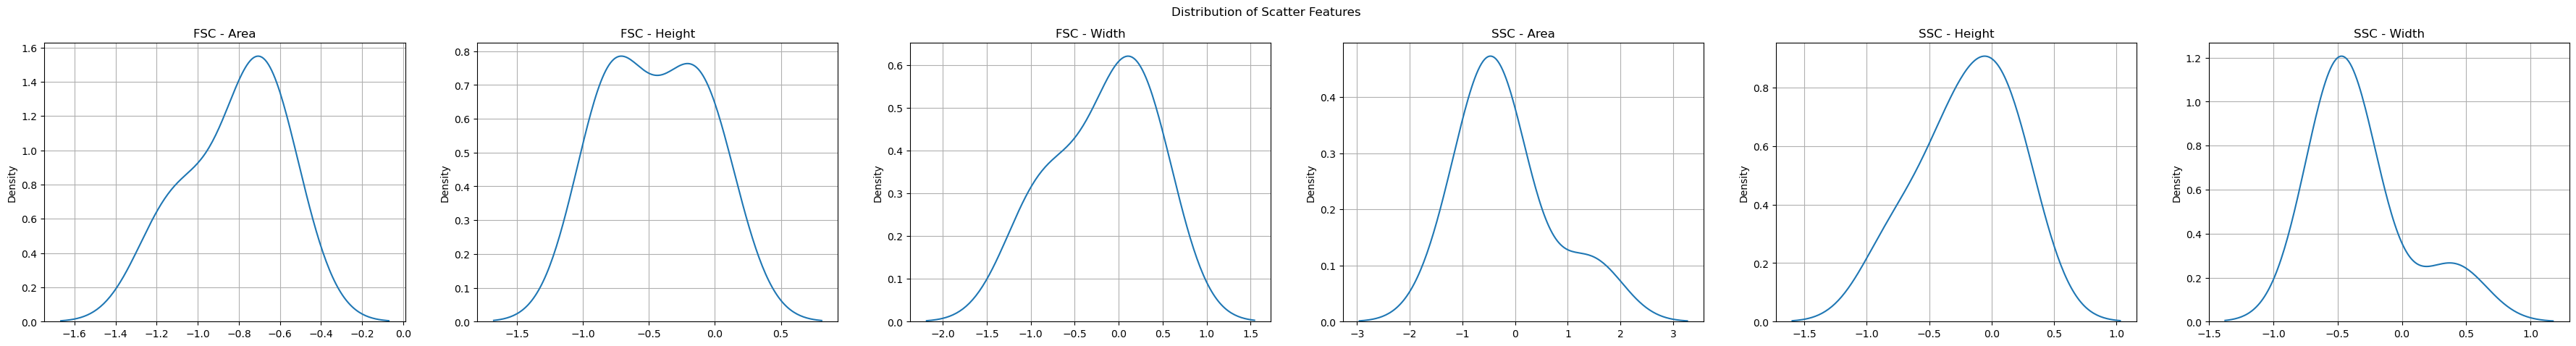

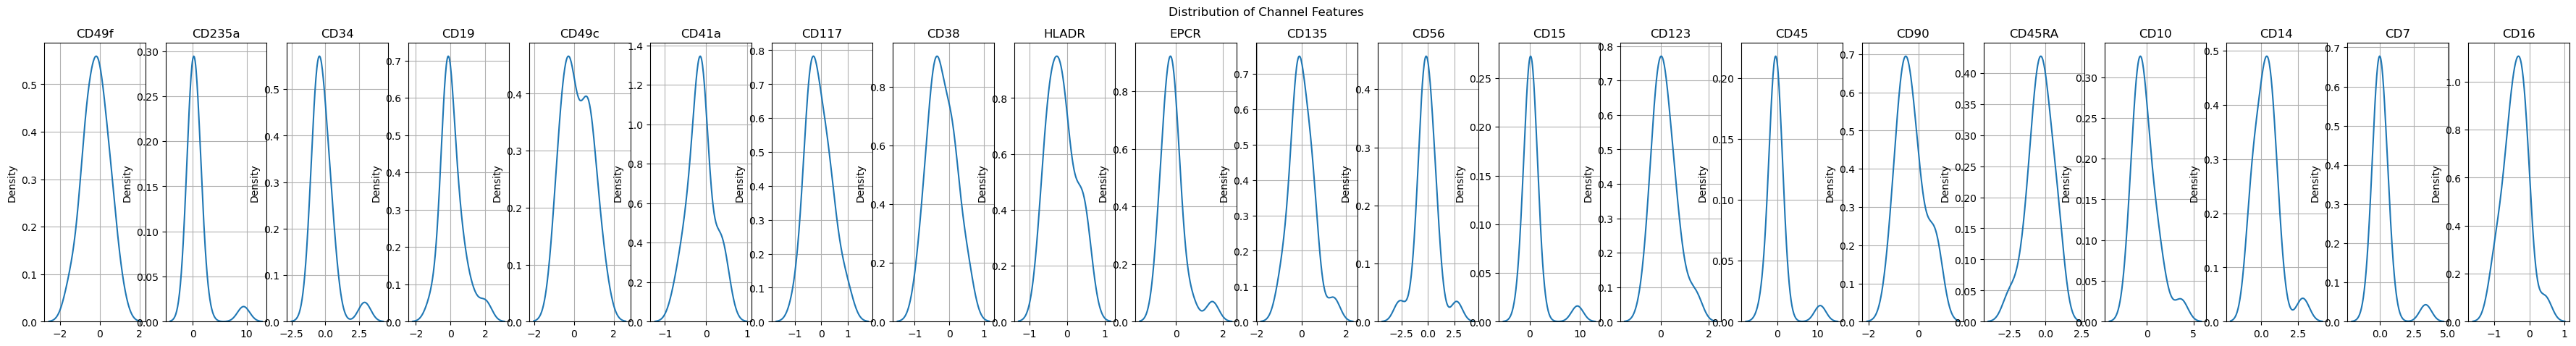

In [ ]:
plot_normalized = True

X_scatter = adata.obs[SCATTER_COVARIATES].values
X_scatter.shape

if plot_normalized:
    data = (X_scatter - X_scatter.mean(0, keepdims=True))/X_scatter.std(0, keepdims=True)
else:
    data = X_scatter
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Scatter Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(SCATTER_COVARIATES[idx])

if plot_normalized:
    data = (adata.X - adata.X.mean(0, keepdims=True)) / adata.X.std(0, keepdims=True)
else:
    data = adata.X
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Channel Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(adata.var_names[idx])


### Splitting data.

In [ ]:
train_adata, val_adata = train_test_split(adata, test_size=VALIDATION_SIZE, random_state=RANDOM_SEED)
print("train", train_adata)
print("val", val_adata)

train View of AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_scatter'
    layer

### Retrieving target cell types and label encoding them.

In [ ]:
# strings
Y_train = train_adata.obs["cell_type"].values
Y_val = val_adata.obs["cell_type"].values

# labels
Y_train_labels = le_cell_type.transform(Y_train)
Y_val_labels = le_cell_type.transform(Y_val)
print(f"{Y_train.shape=}, {Y_val.shape=}")
print(f"{Y_train_labels.shape=}, {Y_val_labels.shape=}")

Y_train.shape=(70000,), Y_val.shape=(30000,)
Y_train_labels.shape=(70000,), Y_val_labels.shape=(30000,)


### Retrieving state representations `X_channel`, `X_scatter`

In [ ]:
# channel features
X_channel_train = train_adata.X
X_channel_val = val_adata.X

# scatter features
X_scatter_train = train_adata.obsm[X_SCATTER_OBSM_KEY]
X_scatter_val = val_adata.obsm[X_SCATTER_OBSM_KEY]
print(f"{X_channel_train.shape=}, {X_channel_val.shape=}")
print(f"{X_scatter_train.shape=}, {X_scatter_val.shape=}")

X_channel_train.shape=(70000, 21), X_channel_val.shape=(30000, 21)
X_scatter_train.shape=(70000, 6), X_scatter_val.shape=(30000, 6)


### Computing mean and standard deviation from train data.

In [ ]:
# channel features
X_channel_mean = X_channel_train.mean(0)
X_channel_std = X_channel_train.std(0)

# scatter features
X_scatter_mean = X_scatter_train.mean(0)
X_scatter_std = X_scatter_train.std(0)
print(f"{X_channel_mean.shape=}, {X_channel_std.shape=}")
print(f"{X_scatter_mean.shape=}, {X_scatter_std.shape=}")


X_channel_mean.shape=(21,), X_channel_std.shape=(21,)
X_scatter_mean.shape=(6,), X_scatter_std.shape=(6,)


### Applying standardization.

In [ ]:
# channel features
X_channel_train_norm = (X_channel_train - X_channel_mean)/X_channel_std
X_channel_val_norm = (X_channel_val - X_channel_mean)/X_channel_std

# scatter features
X_scatter_train_norm = (X_scatter_train - X_scatter_mean)/X_scatter_std
X_scatter_val_norm = (X_scatter_val - X_scatter_mean)/X_scatter_std
print(f"{X_channel_train_norm.shape=}, {X_channel_val_norm.shape=}")
print(f"{X_scatter_train_norm.shape=}, {X_scatter_val_norm.shape=}")

X_channel_train_norm.shape=(70000, 21), X_channel_val_norm.shape=(30000, 21)
X_scatter_train_norm.shape=(70000, 6), X_scatter_val_norm.shape=(30000, 6)


### Storing the data in a dictionary for easier access.

In [ ]:
data_dict = {
    "X_channel": {"train": X_channel_train, "val": X_channel_val},
    "X_channel_norm": {"train": X_channel_train_norm, "val": X_channel_val_norm},
    "X_scatter": {"train": X_scatter_train, "val": X_scatter_val},
    "X_scatter_norm": {"train": X_scatter_train_norm, "val": X_scatter_val_norm},
    "X_concat": {"train": np.concatenate((X_channel_train, X_scatter_train), axis=1), "val": np.concatenate((X_channel_val, X_scatter_val), axis=1)},
    "X_concat_norm": {"train": np.concatenate((X_channel_train_norm, X_scatter_train_norm), axis=1), "val": np.concatenate((X_channel_val_norm, X_scatter_val_norm), axis=1)},
}

### Storing states in `.obsm`.

In [ ]:
for data_mode, val in data_dict.items():
    train_adata.obsm[data_mode] = val["train"]
    val_adata.obsm[data_mode] = val["val"]

/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_4996/1712721153.py:2: ImplicitModificationWarning: Setting element `.obsm['X_channel']` of view, initializing view as actual.
  train_adata.obsm[data_mode] = val["train"]
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_4996/1712721153.py:3: ImplicitModificationWarning: Setting element `.obsm['X_channel']` of view, initializing view as actual.
  val_adata.obsm[data_mode] = val["val"]


### Defining dictionary of DataManagers.

In [ ]:
dm_dict = {}
for data_mode in data_dict.keys():
    dm_dict[data_mode] = sc_exp_design.data.DataManager(
        train_adata,
        sample_rep=data_mode,
        load_target_covariates=True,
        target_covariates={"cell_type": "label"}
    )

### Retrieving data.

In [ ]:
data_dict = {}
for data_mode, dm in dm_dict.items():
    data_dict[data_mode] = {
        "train": dm.get_data(train_adata),
        "val": dm.get_data(val_adata),
    }

### Initializing dataloaders.

In [ ]:
batch_size = 512
dl_dict = {}
for data_mode, data in data_dict.items():
    dl_dict[data_mode] =  sc_exp_design.data.SequentialDataLoader(
        data["train"],
        batch_size=batch_size,
        device_id=DEVICE,
    )


## MLP (Fitting one model per data setting).

### Computing class weights.

In [ ]:
class_weights = torch.from_numpy(compute_class_weight("balanced", classes=np.unique(Y_train), y=Y_train)).float().to(DEVICE)
class_weights

tensor([ 2.9616,  0.7969,  4.5710, 29.4737, 10.9649,  8.0972,  0.8111,  1.1752,
         1.6558,  0.3810,  0.3689,  5.2333,  6.6622,  0.6462,  0.8979,  0.3050,
        23.1711, 11.4416,  0.3991], device='mps:0')

### Initializing models.

In [ ]:
models_dict = {}
for data_mode, data in data_dict.items():
    mlp_target_prediction_model = sc_exp_design.networks.PerturbationApproximatePosterior(
        data["train"].state_data.shape[1],
        freeze_grads=False,
        target_output_dims={"cell_type": adata.obs.cell_type.nunique()},
        noise_models={"cell_type": None},
        covariate_kwargs={
            "cell_type":{
                "hidden_dims": (256, 256),
                "activation_class": torch.nn.ReLU,
                "use_dropout": False,
                "use_batchnorm": False,
                "final_activation_class": torch.nn.Identity,
            }
        }
    )
    mlp_target_prediction_model = mlp_target_prediction_model.float()
    mlp_target_prediction_model = mlp_target_prediction_model.to(DEVICE)
    models_dict[data_mode] = mlp_target_prediction_model


### Training each model.

Loss: 0.0365: 100%|██████████| 15000/15000 [00:51<00:00, 290.24it/s]


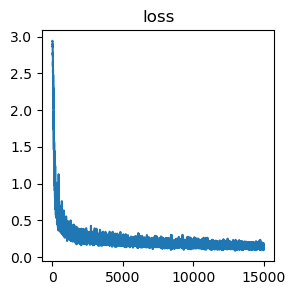

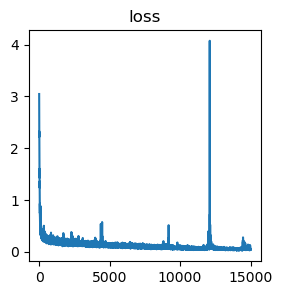

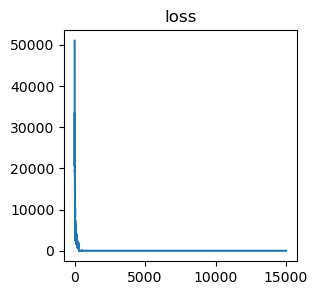

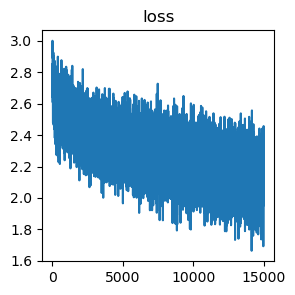

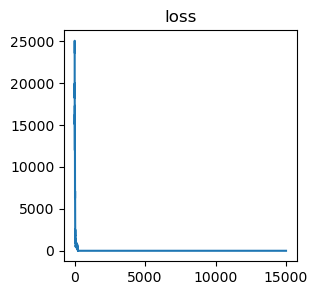

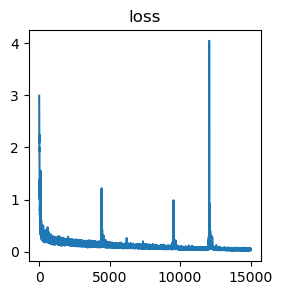

In [ ]:
for data_mode, train_dataloader in dl_dict.items():
    train_data = train_dataloader.data
    mlp_target_prediction_model = models_dict[data_mode]
    mlp_optimizer = torch.optim.Adam(mlp_target_prediction_model.parameters(), lr=1e-3)

    NUM_TRAINING_STEPS = 15_000

    mlp_trainer = sc_exp_design.training.TargetPredictionTrainer(
        mlp_target_prediction_model,
        mlp_optimizer,
        loss_fn_kwargs={"weight":class_weights}
    )
    mlp_trainer.fit(
        NUM_TRAINING_STEPS,
        train_dataloader,
    )
    mlp_trainer.plot_training_logs()

### Evaluating classifier.

In [ ]:
eval_dict = {}
pbar = tqdm(range(len(data_dict)))
for data_mode, value in tqdm(data_dict.items()):
    pbar.set_description(desc=f"Evaluating lm on {data_mode}")
    pbar.update()
    X_val = value["val"].state_data
    lm = models_dict[data_mode]
    eval_dict[data_mode] = evaluate_classifier(
        lm, X_val, Y_val, Y_val_labels, le_cell_type
    )


Evaluating lm on X_scatter:  50%|█████     | 3/6 [00:01<00:01,  2.20it/s]     /Users/lorenzo.consoli/micromamba/envs/sc-exp-design/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lorenzo.consoli/micromamba/envs/sc-exp-design/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lorenzo.consoli/micromamba/envs/sc-exp-design/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

### Visualizing confusion matrices.

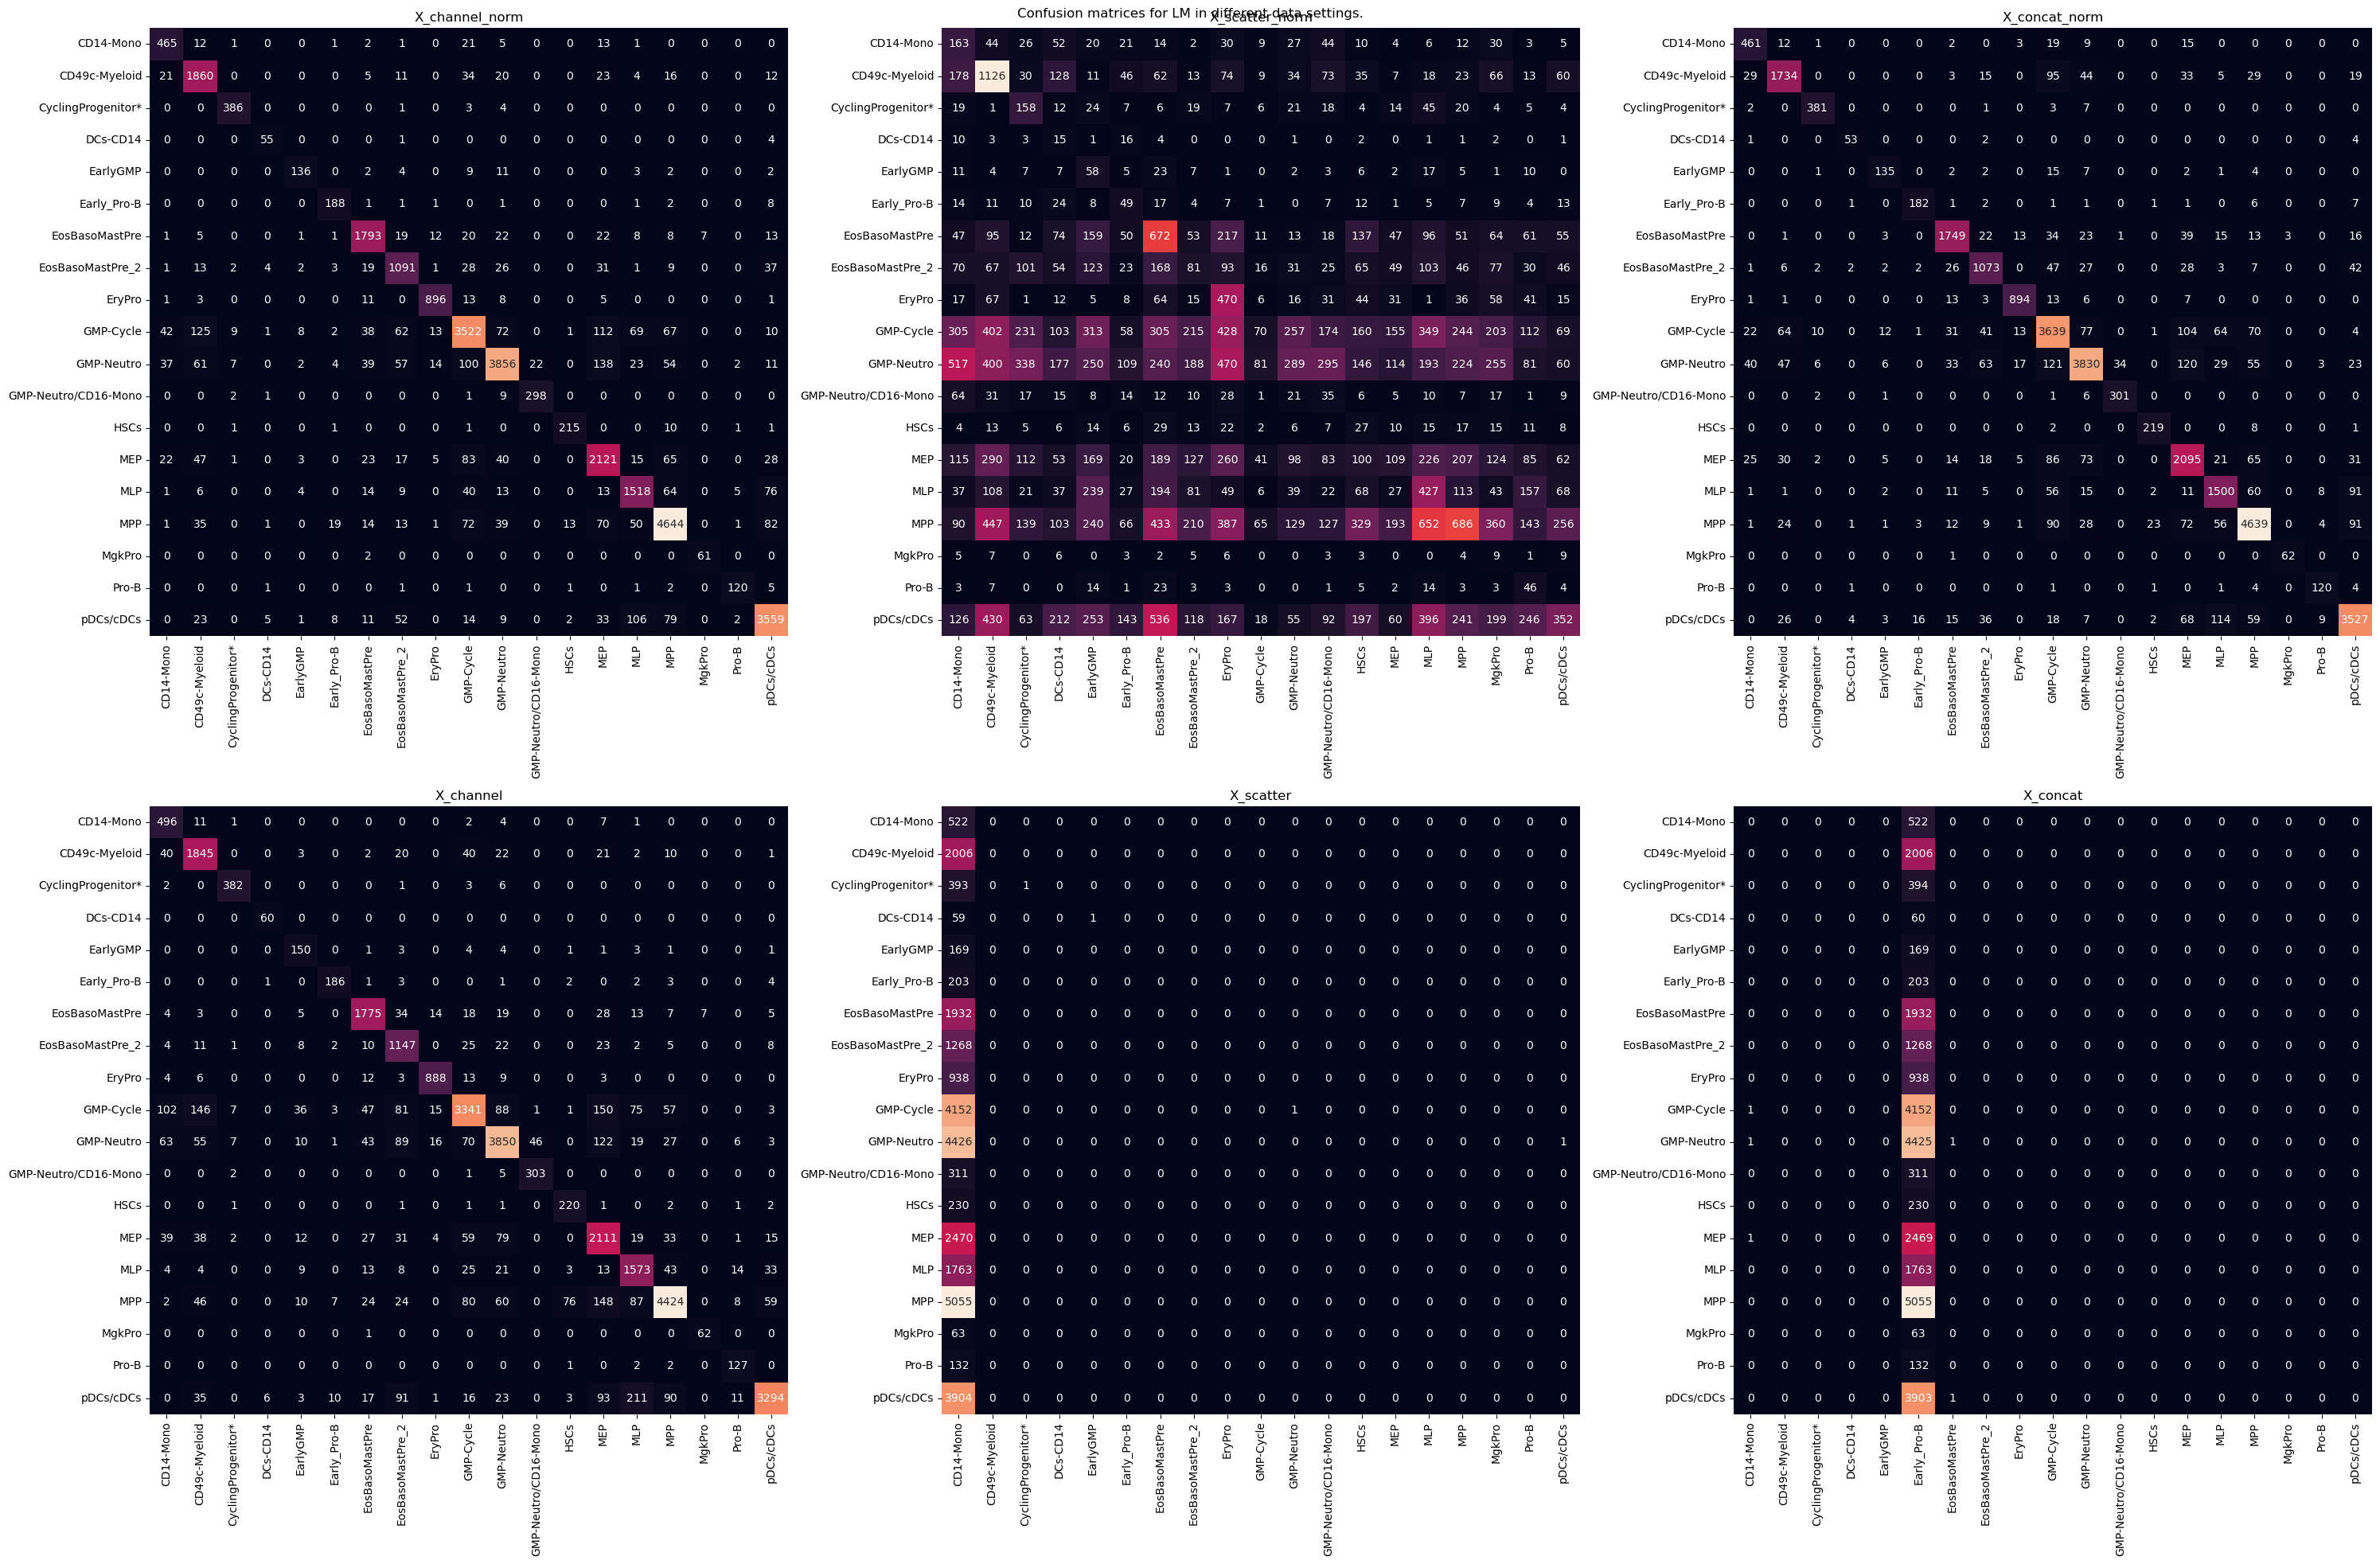

In [ ]:
# separate norm and non-norm keys
norm_keys = [k for k in eval_dict.keys() if k.endswith("_norm")]
raw_keys  = [k.replace("_norm", "") for k in norm_keys]
fig, axes = plt.subplots(2, 3, figsize=(30, 20))
fig.suptitle("Confusion matrices for LM in different data settings.")

# loop over 3 columns
for col, (norm_key, raw_key) in enumerate(zip(norm_keys, raw_keys)):
    # first row = normalized
    cm_norm = eval_dict[norm_key]["cm"]
    sns.heatmap(
        cm_norm,
        annot=True, fmt="d", cbar=False,
        ax=axes[0, col],
        xticklabels=le_cell_type.classes_,
        yticklabels=le_cell_type.classes_,
        # norm="all"
    )
    axes[0, col].set_title(norm_key)

    # second row = unnormalized
    cm_raw = eval_dict[raw_key]["cm"]
    sns.heatmap(
        cm_raw,
        annot=True, fmt="d", cbar=False,
        ax=axes[1, col],
        xticklabels=le_cell_type.classes_,
        yticklabels=le_cell_type.classes_,
        # norm="all"
    )
    axes[1, col].set_title(raw_key)

plt.tight_layout()
plt.show()

### Visualizing classification metrics.

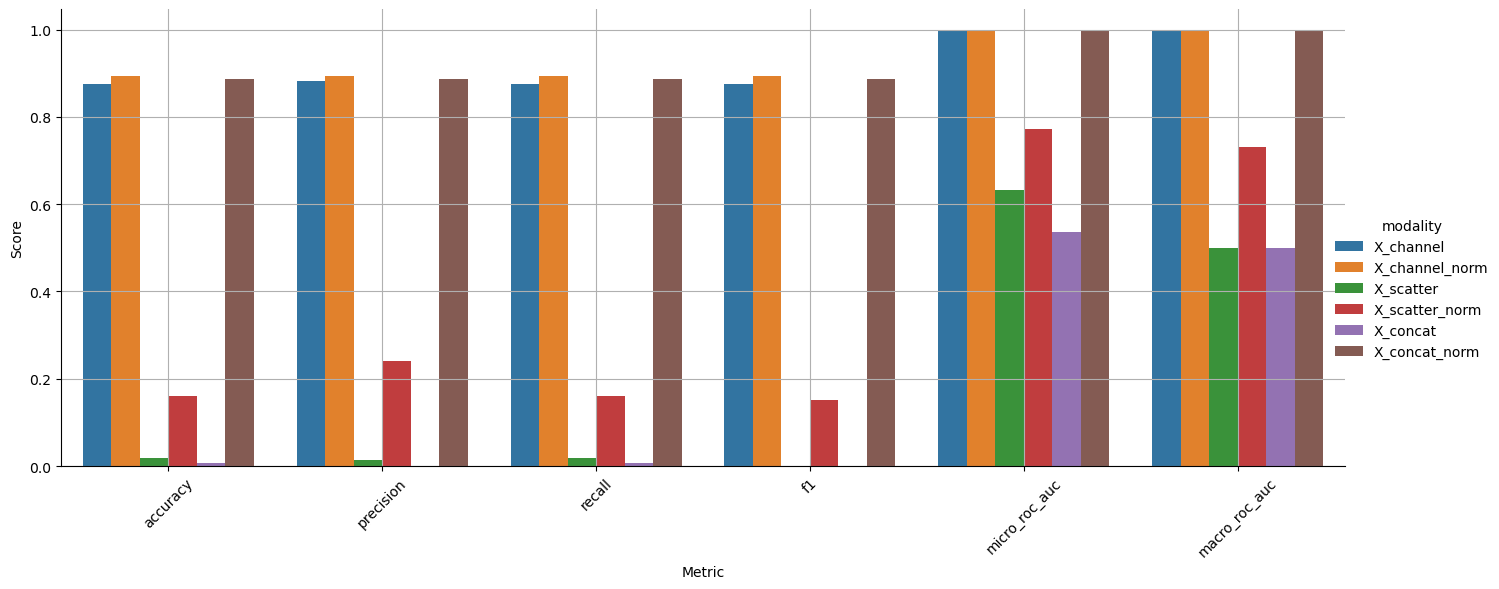

In [ ]:
# metrics you want to compare
metrics = ["accuracy", "precision", "recall", "f1", "micro_roc_auc", "macro_roc_auc"]

# build dataframe
records = []
for modality, results in eval_dict.items():
    for metric in metrics:
        if metric in results:
            records.append({
                "modality": modality,
                "metric": metric,
                "value": results[metric]
            })

df = pd.DataFrame(records)

# plot: grouped barplots, one per metric
g = sns.catplot(
    data=df,
    kind="bar",
    x="metric", y="value", hue="modality",
    height=6, aspect=2
)
g.set_axis_labels("Metric", "Score")
g.set_titles("Comparison of Metrics Across Modalities")
# move legend to the right
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)  # optional: remove legend frame

plt.grid(1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plotting the same information but as a heatmap. 

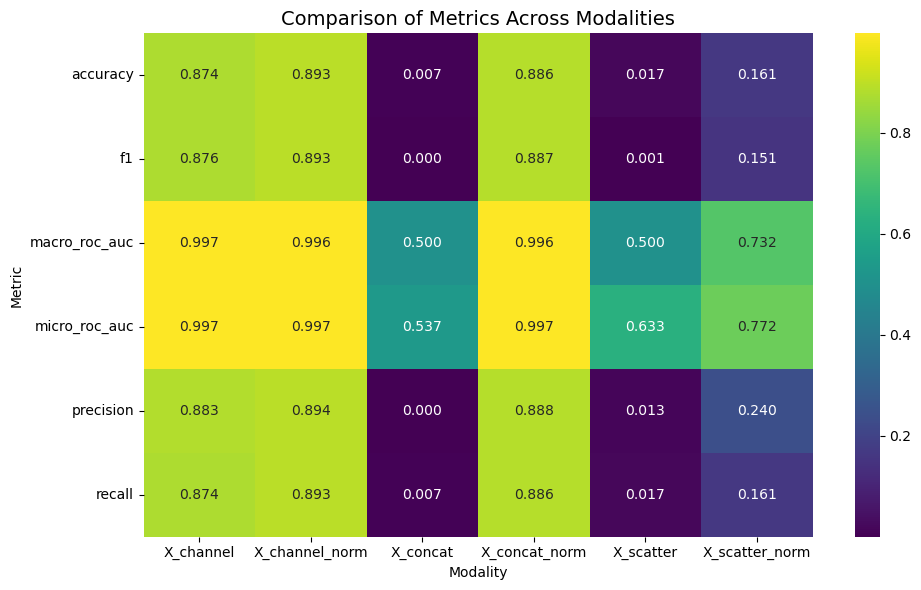

In [ ]:
# pivot for heatmap
heatmap_df = df.pivot(index="metric", columns="modality", values="value")

# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, cmap="viridis", fmt=".3f")
plt.title("Comparison of Metrics Across Modalities", fontsize=14)
plt.xlabel("Modality")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()

### Displaying per class metrics.

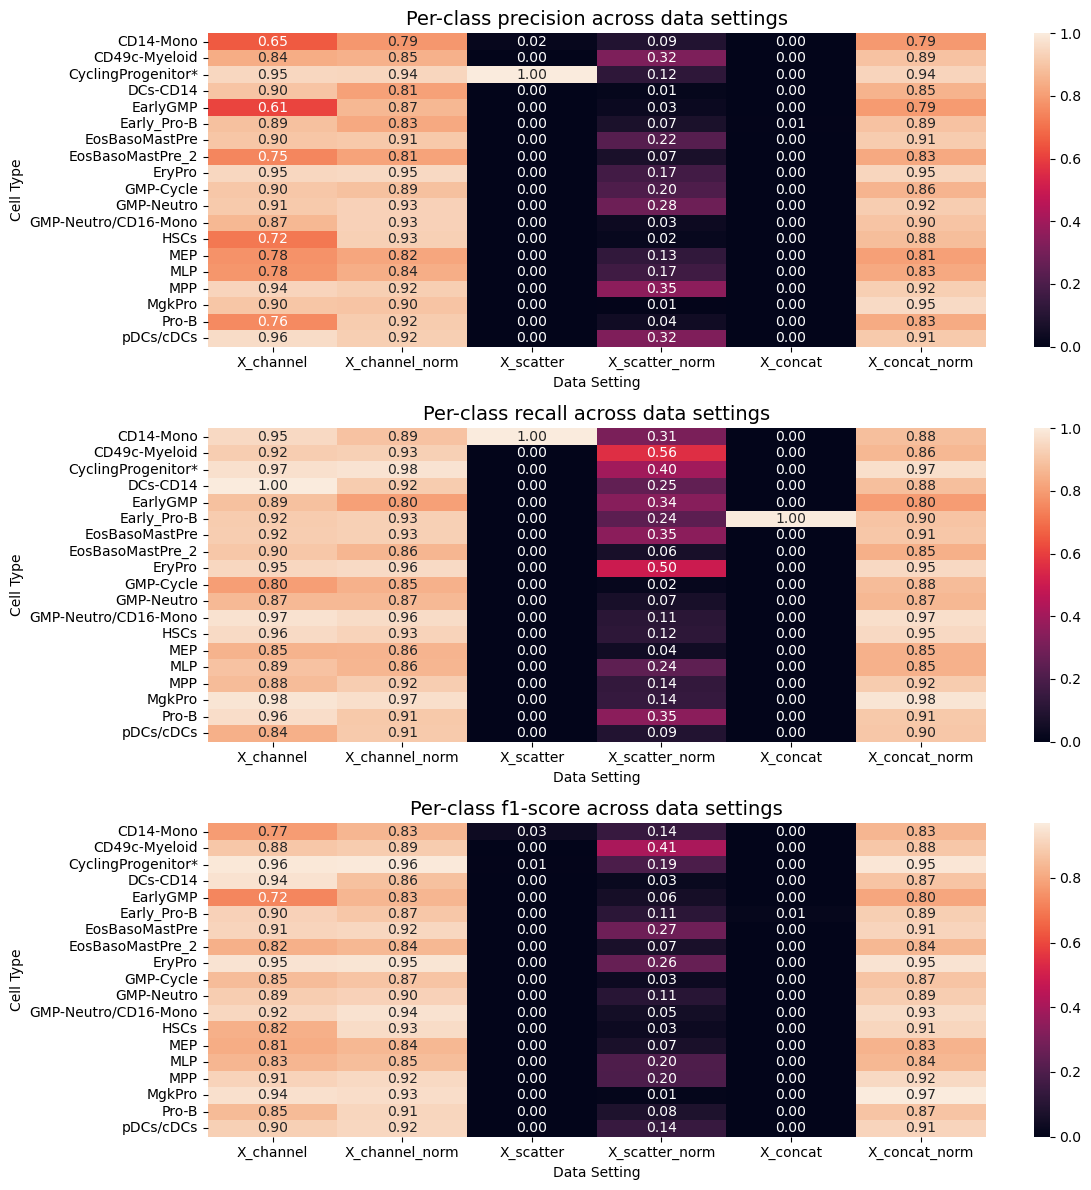

In [ ]:
# metrics to visualize
metrics_to_plot = ["precision", "recall", "f1-score"]

# prepare one dataframe per metric
dfs = {}
for metric in metrics_to_plot:
    df_dict = {}
    for setting, metrics in eval_dict.items():
        report = metrics["report"]  # sklearn classification_report(dict_output=True)
        per_class_scores = {
            cls: vals[metric]
            for cls, vals in report.items()
            if cls not in ("accuracy", "macro avg", "weighted avg")
        }
        df_dict[setting] = per_class_scores
    dfs[metric] = pd.DataFrame(df_dict)

# plot heatmaps
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 4 * len(metrics_to_plot)))

if len(metrics_to_plot) == 1:
    axes = [axes]  # ensure iterable if only one plot

for ax, metric in zip(axes, metrics_to_plot):
    sns.heatmap(dfs[metric], annot=True, fmt=".2f", ax=ax,yticklabels=le_cell_type.classes_)
    ax.set_title(f"Per-class {metric} across data settings", fontsize=14)
    ax.set_xlabel("Data Setting")
    ax.set_ylabel("Cell Type")

plt.tight_layout()
plt.show()


### Plotting misclassified celll in the umap.

In [ ]:
plot_umaps = False
if plot_umaps:
    plot_class_misclassification_entropy(val_adata, eval_dict)
